# 01 — Exploratory Data Analysis & Preprocessing

**Goal**: Load competition data, understand its structure, clean sequences, and save processed files.

**Verify gates**:
- Shapes, dtypes, class balance
- Sequence length & amino acid distributions
- Alphabet validation & duplicate analysis
- Save cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Dark theme for publication-quality plots
plt.style.use('dark_background')
sns.set_palette('viridis')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print('Libraries loaded ✓')

Libraries loaded ✓


## Step 1.1 — Load Data

In [2]:
# Note: CSVs use '#' as comment chars in the header row
train_df = pd.read_csv('../data/raw/train.csv', comment='#', header=None, names=['Sequence', 'Label'])
test_df  = pd.read_csv('../data/raw/test.csv',  comment='#', header=None, names=['ID', 'Sequence'])
sample_df = pd.read_csv('../data/raw/sample.csv', comment='#', header=None, names=['ID', 'Label'])

print(f'Train shape: {train_df.shape}')
print(f'Test  shape: {test_df.shape}')
print(f'Sample shape: {sample_df.shape}')
print()
print('--- Train ---')
display(train_df.head(10))
print(f'\nDtypes:\n{train_df.dtypes}')
print(f'\nInfo:')
train_df.info()
print()
print('--- Test ---')
display(test_df.head(10))
print(f'\nDtypes:\n{test_df.dtypes}')

Train shape: (7670, 2)
Test  shape: (1917, 2)
Sample shape: (1917, 2)

--- Train ---


,Sequence,Label
0,AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,-1
1,AAAAAAAAAK,-1
2,AAAAAAAIKMLMDLVNERIMALNKKAKK,-1
3,AAAALSRWWLRWWVA,-1
4,AAAARRRR,-1
5,AAAEECEEYCEEEEKTCCGEEDGEPVCAEFCL,1
6,AAAISCVGSKECLPKCKAQGCKSGKCMNKKCKCYC,1
7,AAAISCVGSPECPPKCRAQGCKNGKCMNRKCECYYC,1
8,AAARLRLLLYLITRR,-1
9,AACKAACKKGAKLILKAAAPLASQVCGPACNAALA,1



Dtypes:
Sequence    object
Label        int64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7670 entries, 0 to 7669
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Sequence  7670 non-null   object
 1   Label     7670 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.0+ KB

--- Test ---


,ID,Sequence
0,10001,KYCKCKSNICKGSSFGMAVCKVRCDSSYCAA
1,10002,RCNQLNCPPNSCCEPTVLSIWDSPKGDAA
2,10003,ARAGMTSGAASLIGLFLMALGAA
3,10004,KKRKALCHAA
4,10005,GTVLRHITKGVHVIPRAIHHAA
5,10006,SCLDQHQGACRSDLCCEESDTRKMLAPAKFKAA
6,10007,GCLDQHKGSCRPDSCCADRVTRKMLAPAKFKAA
7,10008,RKGFCPKPPISKTWCGKLAA
8,10009,RKGPCPKPPISKTWCGRLAA
9,10010,KWWDKKRLAA



Dtypes:
ID           int64
Sequence    object
dtype: object


## Step 1.2 — Check for Missing Values

In [3]:
print('=== Missing Values ===')
print(f'Train nulls:\n{train_df.isnull().sum()}')
print(f'\nTest nulls:\n{test_df.isnull().sum()}')

# Check for empty sequences
empty_train = train_df[train_df['Sequence'].str.strip() == ''].shape[0]
empty_test  = test_df[test_df['Sequence'].str.strip() == ''].shape[0]
print(f'\nEmpty sequences — Train: {empty_train}, Test: {empty_test}')

=== Missing Values ===
Train nulls:
Sequence    0
Label       0
dtype: int64

Test nulls:
ID          0
Sequence    0
dtype: int64

Empty sequences — Train: 0, Test: 0


## Step 1.3 — Class Distribution

Class Distribution:
  Label -1:  4118  (53.7%)
  Label +1:  3552  (46.3%)


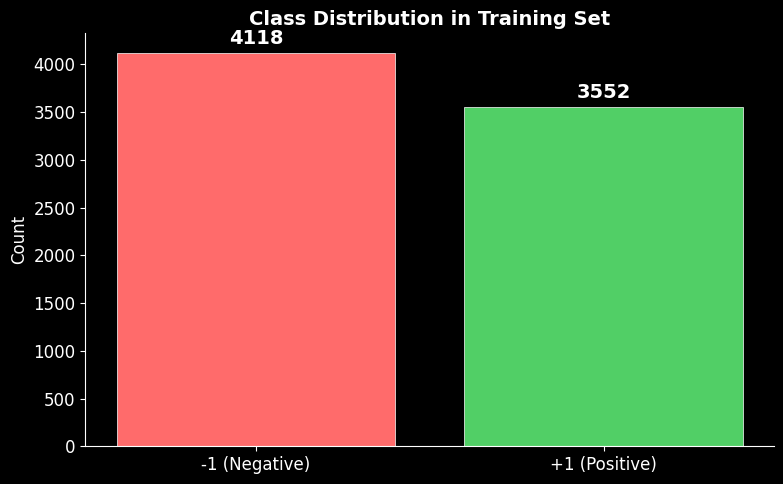

In [4]:
label_counts = train_df['Label'].value_counts()
label_pct = train_df['Label'].value_counts(normalize=True) * 100

print('Class Distribution:')
for label in sorted(label_counts.index):
    print(f'  Label {label:+d}: {label_counts[label]:>5d}  ({label_pct[label]:.1f}%)')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ff6b6b', '#51cf66']  # red for -1, green for +1
bars = ax.bar(['-1 (Negative)', '+1 (Positive)'], 
              [label_counts.get(-1, 0), label_counts.get(1, 0)],
              color=colors, edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, [label_counts.get(-1, 0), label_counts.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.set_title('Class Distribution in Training Set', fontweight='bold')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Step 1.4 — Sequence Length Distribution

=== Sequence Length Stats ===


Train — min: 8, max: 133, median: 20, mean: 21.2
Test  — min: 8, max: 76, median: 20, mean: 21.3


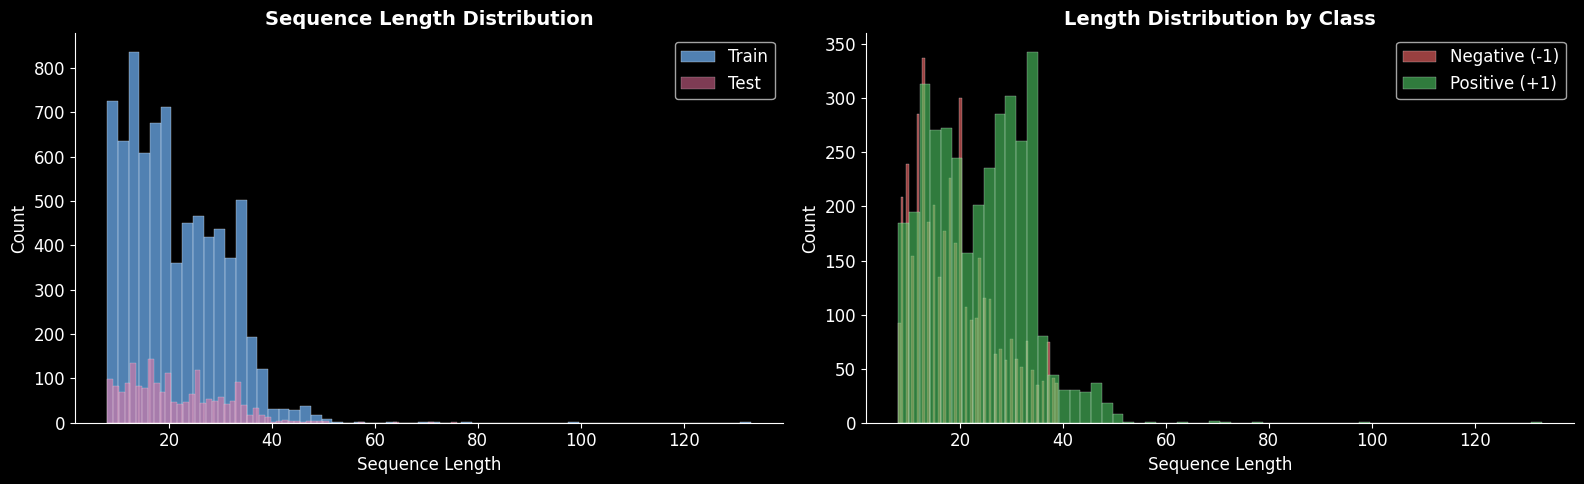

In [5]:
train_df['Length'] = train_df['Sequence'].str.len()
test_df['Length']  = test_df['Sequence'].str.len()

print('=== Sequence Length Stats ===')
print(f'Train — min: {train_df["Length"].min()}, max: {train_df["Length"].max()}, '
      f'median: {train_df["Length"].median():.0f}, mean: {train_df["Length"].mean():.1f}')
print(f'Test  — min: {test_df["Length"].min()}, max: {test_df["Length"].max()}, '
      f'median: {test_df["Length"].median():.0f}, mean: {test_df["Length"].mean():.1f}')

# Overlaid histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(train_df['Length'], bins=60, alpha=0.7, label='Train', color='#74b9ff', edgecolor='white', linewidth=0.3)
axes[0].hist(test_df['Length'],  bins=60, alpha=0.5, label='Test',  color='#fd79a8', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Sequence Length Distribution', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# By class
for label, color, name in [(-1, '#ff6b6b', 'Negative (-1)'), (1, '#51cf66', 'Positive (+1)')]:
    subset = train_df[train_df['Label'] == label]
    axes[1].hist(subset['Length'], bins=60, alpha=0.6, label=name, color=color, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Count')
axes[1].set_title('Length Distribution by Class', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Step 1.5 — Amino Acid Frequency

Total residues: 162,973
Standard AA types found: 20/20
No non-standard characters found ✓


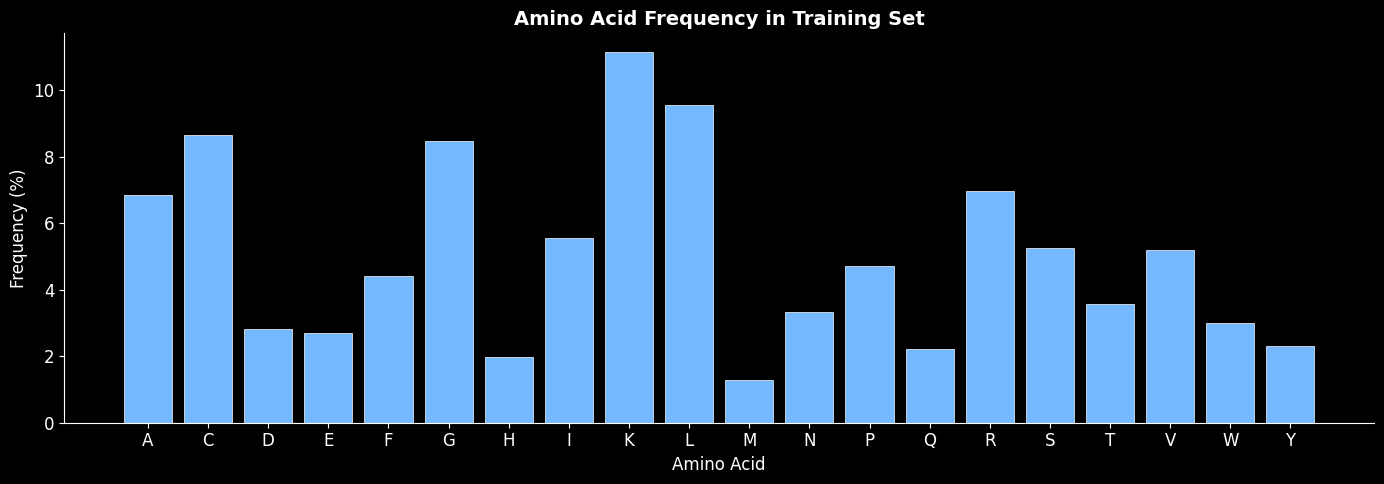

In [6]:
STANDARD_AAS = list('ACDEFGHIKLMNPQRSTVWY')

# Count all amino acids across training sequences
all_chars = ''.join(train_df['Sequence'].str.upper())
char_counts = Counter(all_chars)

# Separate standard vs non-standard
standard_counts = {aa: char_counts.get(aa, 0) for aa in STANDARD_AAS}
non_standard = {k: v for k, v in char_counts.items() if k not in STANDARD_AAS}

print(f'Total residues: {len(all_chars):,}')
print(f'Standard AA types found: {sum(1 for aa in STANDARD_AAS if char_counts.get(aa, 0) > 0)}/20')
if non_standard:
    print(f'Non-standard characters: {non_standard}')
else:
    print('No non-standard characters found ✓')

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
aa_sorted = sorted(standard_counts.keys())
counts_sorted = [standard_counts[aa] for aa in aa_sorted]
total = sum(counts_sorted)
freqs = [c / total * 100 for c in counts_sorted]

bars = ax.bar(aa_sorted, freqs, color='#74b9ff', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Amino Acid')
ax.set_ylabel('Frequency (%)')
ax.set_title('Amino Acid Frequency in Training Set', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Step 1.6 — Alphabet Validation

In [7]:
import re

VALID_PATTERN = re.compile(r'^[ACDEFGHIKLMNPQRSTVWY]+$')

# Check train
train_invalid = train_df[~train_df['Sequence'].str.upper().str.match(VALID_PATTERN)]
print(f'Train sequences with non-standard characters: {len(train_invalid)}')
if len(train_invalid) > 0:
    print('Sample invalid sequences:')
    for _, row in train_invalid.head(5).iterrows():
        invalid_chars = set(row['Sequence'].upper()) - set(STANDARD_AAS)
        print(f'  {row["Sequence"][:40]}... → invalid chars: {invalid_chars}')

# Check test
test_invalid = test_df[~test_df['Sequence'].str.upper().str.match(VALID_PATTERN)]
print(f'\nTest sequences with non-standard characters: {len(test_invalid)}')
if len(test_invalid) > 0:
    for _, row in test_invalid.head(5).iterrows():
        invalid_chars = set(row['Sequence'].upper()) - set(STANDARD_AAS)
        print(f'  {row["Sequence"][:40]}... → invalid chars: {invalid_chars}')

Train sequences with non-standard characters: 0

Test sequences with non-standard characters: 0


## Step 1.7 — Duplicate Analysis

In [8]:
# Exact duplicates within train (same sequence, same label)
exact_dups = train_df.duplicated(subset=['Sequence', 'Label'], keep=False)
print(f'Exact duplicates (same seq + same label): {exact_dups.sum()} rows '
      f'({train_df[exact_dups]["Sequence"].nunique()} unique sequences)')

# Conflicting labels (same sequence, different labels)
seq_label_counts = train_df.groupby('Sequence')['Label'].nunique()
conflicting = seq_label_counts[seq_label_counts > 1]
print(f'\nConflicting labels (same seq, different labels): {len(conflicting)} sequences')
if len(conflicting) > 0:
    print('\nSample conflicting sequences:')
    for seq in conflicting.index[:10]:
        labels = train_df[train_df['Sequence'] == seq]['Label'].tolist()
        print(f'  {seq[:40]}... → labels: {labels}')

# Overlap between train and test sequences
train_seqs = set(train_df['Sequence'].str.upper())
test_seqs  = set(test_df['Sequence'].str.upper())
overlap = train_seqs & test_seqs
print(f'\nTrain-Test sequence overlap: {len(overlap)} sequences')
if len(overlap) > 0:
    print('  (These could be used for exact-match prediction!)')
    for seq in list(overlap)[:5]:
        print(f'  {seq[:50]}...')

Exact duplicates (same seq + same label): 2 rows (1 unique sequences)

Conflicting labels (same seq, different labels): 526 sequences

Sample conflicting sequences:
  AAGMGFFGAR... → labels: [1, -1]
  AAPRGGKGFFCKLFKDC... → labels: [1, -1]
  ACDFQQCWVTCQRQYSINFISARCNGDSCVCTFRT... → labels: [1, -1]
  ACQFWSCNSSCISRGYRQGYCWGIQYKYCQCQ... → labels: [1, -1]
  ACYCRIPACIAGERRYGTCIYQGRLWAFCC... → labels: [1, -1]
  ADVRNPLEEFRETDYEVL... → labels: [1, -1]
  AGWGSIFKHIFKAGKFIHGAIQAHND... → labels: [1, -1]
  AINPKSVQSLL... → labels: [1, -1]
  AIPCGESCVWIPCISTVIGCSCSNKVCYR... → labels: [1, -1]
  AIPWIWIWRLLRKG... → labels: [1, -1]

Train-Test sequence overlap: 10 sequences
  (These could be used for exact-match prediction!)
  LWRLWWLWW...
  CWKWKWKWGSGWKWKWKWC...
  ILPKKWPKLPWRR...
  VFLRRIRVIVIR...
  RRWPLKPWKKPLI...


## Step 1.8 — Clean & Save

In [9]:
# --- Cleaning pipeline ---

# 1. Uppercase + strip
train_clean = train_df.copy()
test_clean  = test_df.copy()
train_clean['Sequence'] = train_clean['Sequence'].str.upper().str.strip()
test_clean['Sequence']  = test_clean['Sequence'].str.upper().str.strip()

# 2. Handle conflicting labels: keep majority vote, if tied keep +1 (optimistic)
if len(conflicting) > 0:
    print(f'Resolving {len(conflicting)} conflicting sequences...')
    # For conflicting sequences, take majority vote
    def resolve_conflict(group):
        label_counts = group['Label'].value_counts()
        majority_label = label_counts.index[0]  # most frequent
        return group.head(1).assign(Label=majority_label)
    
    conflict_seqs = set(conflicting.index)
    clean_no_conflict = train_clean[~train_clean['Sequence'].isin(conflict_seqs)]
    clean_conflict = train_clean[train_clean['Sequence'].isin(conflict_seqs)]
    resolved = clean_conflict.groupby('Sequence', group_keys=False).apply(resolve_conflict)
    train_clean = pd.concat([clean_no_conflict, resolved], ignore_index=True)

# 3. Remove exact duplicates (keep first)
before = len(train_clean)
train_clean = train_clean.drop_duplicates(subset=['Sequence', 'Label'], keep='first')
print(f'Removed {before - len(train_clean)} exact duplicate rows')

# 4. Recompute length
train_clean['Length'] = train_clean['Sequence'].str.len()
test_clean['Length']  = test_clean['Sequence'].str.len()

print(f'\nFinal train shape: {train_clean.shape}')
print(f'Final test shape:  {test_clean.shape}')
print(f'\nFinal class distribution:')
print(train_clean['Label'].value_counts())

Resolving 526 conflicting sequences...


Removed 1 exact duplicate rows



Final train shape: (7143, 3)
Final test shape:  (1917, 3)

Final class distribution:
Label
-1    3591
 1    3552
Name: count, dtype: int64


In [10]:
# Save cleaned data
train_clean.to_csv('../data/processed/train_clean.csv', index=False)
test_clean.to_csv('../data/processed/test_clean.csv', index=False)

# Verify
verify_train = pd.read_csv('../data/processed/train_clean.csv')
verify_test  = pd.read_csv('../data/processed/test_clean.csv')
assert verify_train.shape == train_clean.shape, 'Train shape mismatch!'
assert verify_test.shape  == test_clean.shape,  'Test shape mismatch!'
assert verify_train.isnull().sum().sum() == 0, 'Train has nulls!'

print(f'Saved train_clean.csv ({verify_train.shape}) ✓')
print(f'Saved test_clean.csv  ({verify_test.shape}) ✓')
print('\n=== Phase 1 Complete ===')

Saved train_clean.csv ((7143, 3)) ✓
Saved test_clean.csv  ((1917, 3)) ✓

=== Phase 1 Complete ===
